# 🔍 Stage 3: Case Retrieval
## Sistem CBR Putusan Pengadilan - Pidana Umum Penggelapan

**Tujuan Notebook ini:**
- Melatih TF-IDF Vectorizer pada teks putusan
- Melatih model SVM untuk klasifikasi kategori hukuman
- Mengimplementasikan fungsi `retrieve(query, top_k=5)`
- Menyimpan model ke folder `models/`

**Pendekatan:**
```
Teks Kasus Baru
    ↓
TF-IDF Vectorization
    ↓
Cosine Similarity (vs Case Base)
    ↓
Top-K Kasus Paling Mirip
```

**Konsep CBR:**
> Case Retrieval adalah proses mencari kasus-kasus historis yang paling mirip dengan kasus baru. Ini adalah inti dari sistem CBR.

---

In [2]:
import sys, os
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity

from retrieval import (
    train_tfidf, train_svm, retrieve, build_retrieval_system
)

print('✅ Library berhasil diimport!')

✅ Library berhasil diimport!


## Step 3.1: Load Data dari Stage 2

In [3]:
CASES_CSV = Path('..') / 'data' / 'processed' / 'cases.csv'
MODEL_DIR = Path('..') / 'models'

df = pd.read_csv(CASES_CSV, encoding='utf-8-sig')
print(f'Data dimuat: {len(df)} kasus')
print(f'Kolom: {list(df.columns)}')
df[['case_id', 'kategori_hukuman', 'jumlah_kata']].head(5)

Data dimuat: 106 kasus
Kolom: ['case_id', 'nomor_perkara', 'tanggal_putusan', 'pasal', 'nama_terdakwa', 'nama_hakim', 'jumlah_kata', 'jumlah_kalimat', 'panjang_dokumen', 'ringkasan_fakta', 'amar_putusan', 'kategori_hukuman', 'cleaned_text']


,case_id,kategori_hukuman,jumlah_kata
0,CASE_001,berat,6025
1,CASE_002,ringan,23884
2,CASE_003,ringan,11160
3,CASE_004,berat,9529
4,CASE_005,ringan,7538


## Step 3.2: Membangun Sistem Retrieval

Pipeline:
1. Split 80% train, 20% test
2. Latih TF-IDF
3. Latih SVM
4. Simpan model

In [4]:
# Bangun dan simpan sistem retrieval
print('Membangun sistem retrieval...')
system = build_retrieval_system(str(CASES_CSV), str(MODEL_DIR))

print('\n✅ Sistem retrieval berhasil dibangun!')
print(f'Training samples : {len(system["df_train"])}')
print(f'Test samples     : {len(system["df_test"])}')
print(f'Fitur TF-IDF     : {system["X_train"].shape[1]}')
print(f'\nDistribusi label training:')
print(system['df_train']['kategori_hukuman'].value_counts())

2026-06-18 19:04:23,021 - INFO - Loading data dari: ..\data\processed\cases.csv
2026-06-18 19:04:23,069 - INFO - Total kasus valid: 103
2026-06-18 19:04:23,088 - INFO - Train: 82 | Test: 21
2026-06-18 19:04:23,088 - INFO - Melatih TF-IDF dengan max_features=5000...


Membangun sistem retrieval...


2026-06-18 19:04:23,786 - INFO - TF-IDF matrix shape: (82, 5000)
2026-06-18 19:04:23,928 - INFO - Melatih model SVM...
2026-06-18 19:04:24,185 - INFO - Model SVM berhasil dilatih!
2026-06-18 19:04:24,897 - INFO - Model tersimpan di folder: ..\models/



✅ Sistem retrieval berhasil dibangun!
Training samples : 82
Test samples     : 21
Fitur TF-IDF     : 5000

Distribusi label training:
kategori_hukuman
ringan    43
berat     39
Name: count, dtype: int64


## Step 3.3: Visualisasi TF-IDF (Top Kata)

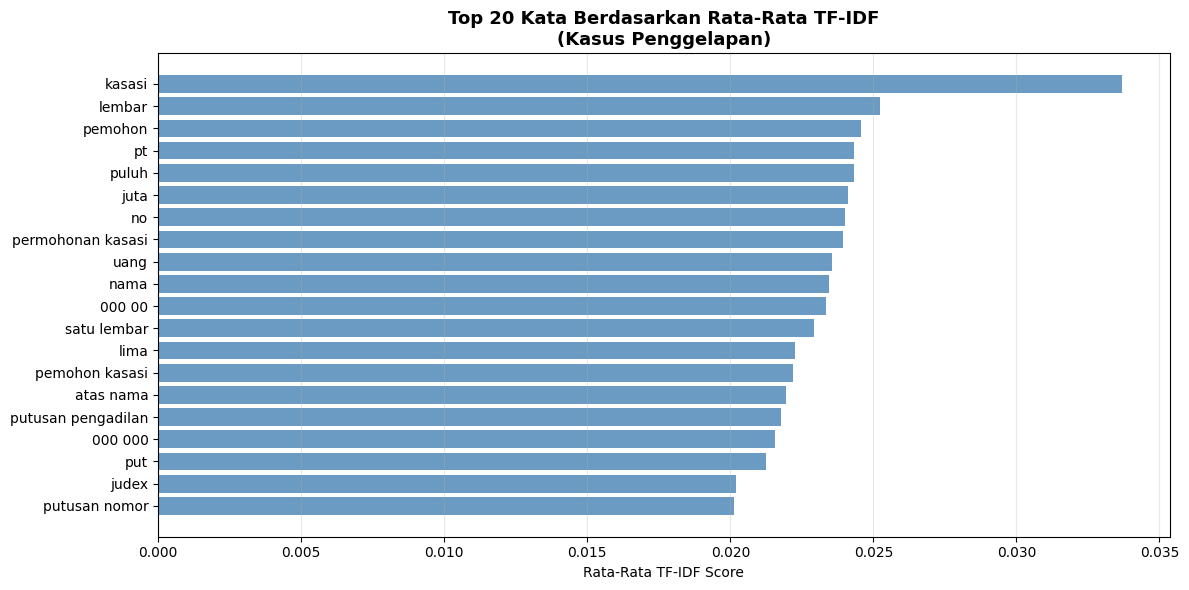

✅ Visualisasi disimpan: outputs/stage3_tfidf_kata.png


In [5]:
# Tampilkan kata-kata dengan nilai TF-IDF tertinggi
vectorizer = system['vectorizer']
feature_names = vectorizer.get_feature_names_out()

# Rata-rata TF-IDF per kata
tfidf_mean = system['X_train'].mean(axis=0).A1
top_n = 20
top_idx = tfidf_mean.argsort()[::-1][:top_n]
top_words = [feature_names[i] for i in top_idx]
top_scores = [tfidf_mean[i] for i in top_idx]

plt.figure(figsize=(12, 6))
bars = plt.barh(top_words[::-1], top_scores[::-1], color='steelblue', alpha=0.8)
plt.title(f'Top {top_n} Kata Berdasarkan Rata-Rata TF-IDF\n(Kasus Penggelapan)',
           fontsize=13, fontweight='bold')
plt.xlabel('Rata-Rata TF-IDF Score')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../outputs/stage3_tfidf_kata.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi disimpan: outputs/stage3_tfidf_kata.png')

## Step 3.4: Demo Fungsi Retrieve

In [6]:
# =====================================================
# DEMO UTAMA: Fungsi retrieve()
# =====================================================

query_baru = """
terdakwa merupakan seorang bendahara yang dipercaya mengurus keuangan perusahaan.
terdakwa menggelapkan uang sebesar rp 50 juta yang dipercayakan kepadanya.
perbuatan dilakukan selama 3 bulan secara berulang.
terdakwa terbukti melanggar pasal 374 kuhp tentang penggelapan dalam jabatan.
"""

print('QUERY KASUS BARU:')
print('=' * 60)
print(query_baru.strip())
print('\n' + '=' * 60)
print('TOP 5 KASUS PALING MIRIP:')
print('=' * 60)

hasil = retrieve(
    query=query_baru,
    vectorizer=system['vectorizer'],
    tfidf_matrix=system['tfidf_matrix'],
    df_cases=system['df_all'],
    top_k=5
)

# Tampilkan hasil
for i, row in hasil.iterrows():
    print(f"\nRank {i+1}:")
    print(f"  Case ID         : {row.get('case_id', '?')}")
    print(f"  Similarity Score: {row.get('similarity_score', 0):.4f}")
    print(f"  Kategori Hukuman: {row.get('kategori_hukuman', '?')}")
    print(f"  Amar Putusan    : {str(row.get('amar_putusan', ''))[:100]}...")

2026-06-18 19:04:25,200 - INFO - Ditemukan 5 kasus paling mirip


QUERY KASUS BARU:
terdakwa merupakan seorang bendahara yang dipercaya mengurus keuangan perusahaan.
terdakwa menggelapkan uang sebesar rp 50 juta yang dipercayakan kepadanya.
perbuatan dilakukan selama 3 bulan secara berulang.
terdakwa terbukti melanggar pasal 374 kuhp tentang penggelapan dalam jabatan.

TOP 5 KASUS PALING MIRIP:

Rank 1:
  Case ID         : CASE_031
  Similarity Score: 0.1353
  Kategori Hukuman: berat
  Amar Putusan    : mengadili perkaranya, dengan sengaja dan dengan g e melawan hukum memiliki barang sesuatu berupa uan...

Rank 2:
  Case ID         : CASE_014
  Similarity Score: 0.1105
  Kategori Hukuman: ringan
  Amar Putusan    : mengadili tidak dilaksanakan menurut ketentuan undang-undang, dan i apakah pengadilan telah melampau...

Rank 3:
  Case ID         : CASE_090
  Similarity Score: 0.1004
  Kategori Hukuman: ringan
  Amar Putusan    : mengadili perkara pidana pada tingkat kasasi telah memutuskan sebagai berikut dalam perkara terdakwa...

Rank 4:
  Case ID   

## Step 3.5: Visualisasi Similarity Score

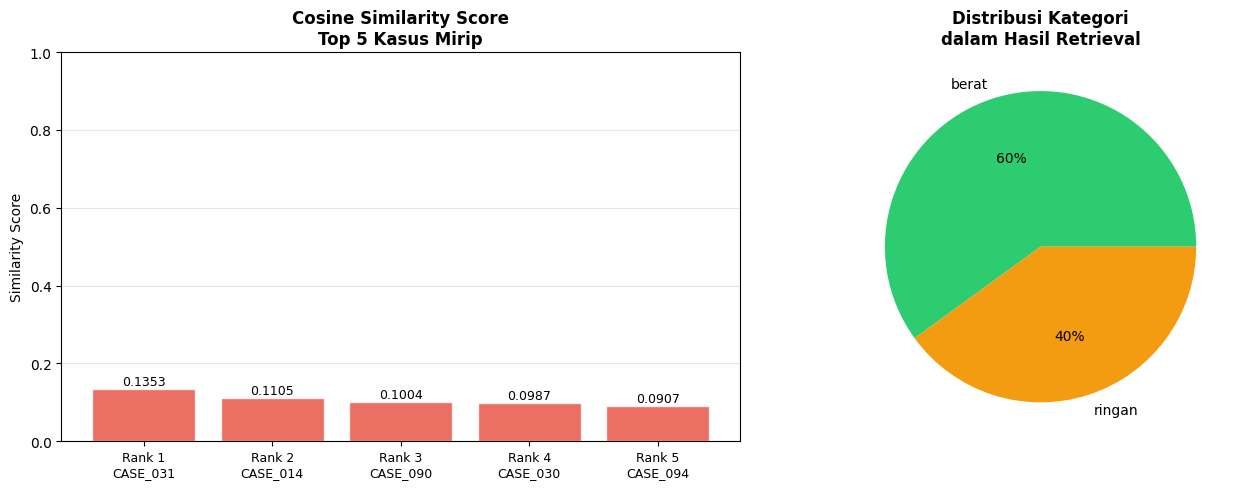

✅ Visualisasi disimpan: outputs/stage3_retrieval_result.png


In [7]:
# Visualisasi similarity score top-5 kasus
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart similarity score
case_ids = hasil['case_id'].tolist()
scores = hasil['similarity_score'].tolist()
colors_bar = ['#2ecc71' if s >= 0.5 else '#f39c12' if s >= 0.3 else '#e74c3c' for s in scores]

axes[0].bar(range(len(case_ids)), scores, color=colors_bar, alpha=0.8, edgecolor='white')
axes[0].set_xticks(range(len(case_ids)))
axes[0].set_xticklabels([f'Rank {i+1}\n{cid}' for i, cid in enumerate(case_ids)], fontsize=9)
axes[0].set_title('Cosine Similarity Score\nTop 5 Kasus Mirip', fontweight='bold')
axes[0].set_ylabel('Similarity Score')
axes[0].set_ylim(0, 1.0)
for i, v in enumerate(scores):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=9)
axes[0].grid(alpha=0.3, axis='y')

# Distribusi kategori dalam hasil retrieval
if 'kategori_hukuman' in hasil.columns:
    kat_counts = hasil['kategori_hukuman'].value_counts()
    axes[1].pie(kat_counts.values, labels=kat_counts.index, autopct='%1.0f%%',
                 colors=['#2ecc71', '#f39c12', '#e74c3c'][:len(kat_counts)])
    axes[1].set_title('Distribusi Kategori\ndalam Hasil Retrieval', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/stage3_retrieval_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi disimpan: outputs/stage3_retrieval_result.png')

In [8]:
# Cek model yang tersimpan
import os
model_files = list(Path('..', 'models').glob('*.pkl'))
print('Model yang tersimpan di folder models/:')
for f in model_files:
    size_kb = f.stat().st_size / 1024
    print(f'  - {f.name} ({size_kb:.1f} KB)')

Model yang tersimpan di folder models/:
  - label_encoder.pkl (0.5 KB)
  - svm_model.pkl (1109.3 KB)
  - tfidf_matrix.pkl (1380.0 KB)
  - tfidf_vectorizer.pkl (195.7 KB)
